In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/q3_retail_promotions.csv')
df = pd.read_csv('../data/q3_retail_promotions.csv')

Mounted at /content/drive


1. Date Feature Engineering

In [ ]:

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

2. Temporal Train-Test Split

In [3]:
df = df.sort_values('transaction_date')

split_index = int(len(df)*0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

Markdown:

Random split causes leakage → future data influences training

3. Preprocessing Pipeline

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [col for col in df.columns if col not in cat_cols + ['items_sold','transaction_date']]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

4. Model Training and Evaluation

In [5]:
# Model Training
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

lr_pipeline.fit(train, train['items_sold'])
rf_pipeline.fit(train, train['items_sold'])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [6]:
# Evaluation

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

for name, model in [('LR', lr_pipeline), ('RF', rf_pipeline)]:
    preds = model.predict(test)
    rmse = np.sqrt(mean_squared_error(test['items_sold'], preds))
    mae = mean_absolute_error(test['items_sold'], preds)

    print(name, rmse, mae)

LR 27.121451164890626 21.052926674588395
RF 30.841610008504205 24.240625


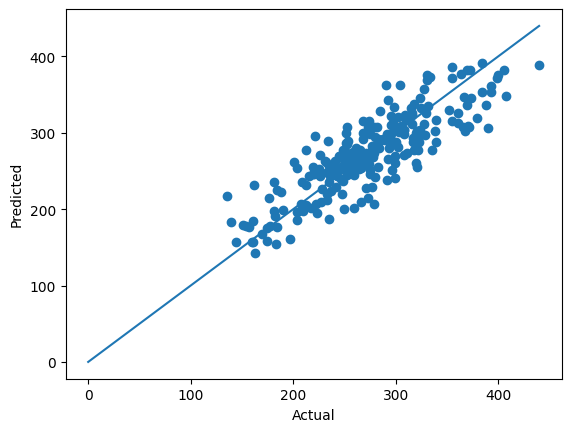

In [7]:
# Parity Plot

plt.scatter(test['items_sold'], preds)
plt.plot([0, max(test['items_sold'])], [0, max(test['items_sold'])])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [8]:
# Feature Importance
rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_

Markdown:

Top drivers: promotion type, store size, competition